In [30]:
import os
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.optim.lr_scheduler import StepLR
from torchvision.transforms import v2
import torchvision
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from multiprocessing import freeze_support
import time
from timed_decorator.simple_timed import timed

from pathlib import Path
import sys
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from torchviz import make_dot

In [2]:

LCL_PATH  = str(Path().cwd())
ROOT_PATH = str(Path(LCL_PATH).parent)
DEEPL_PATH = str(Path(ROOT_PATH)/"deep_learning")
DS_PATH = "{}/data_visualisation/data".format(ROOT_PATH)

print("""
root path:\t{}
local path:\t{}
deep learning path:\t{}
dataset path:\t{}""".format(ROOT_PATH, LCL_PATH, DEEPL_PATH, DS_PATH))


root path:	/home/gheorghe/Desktop/Proiecte/master/CARN
local path:	/home/gheorghe/Desktop/Proiecte/master/CARN/laborator_10
deep learning path:	/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning
dataset path:	/home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data


In [3]:

# adding local_folder to the system path
sys.path.append(ROOT_PATH)
sys.path.append(LCL_PATH)
sys.path.append(DEEPL_PATH)

from sys_function import * # este in root

In [40]:

sys_remove_modules("layers.resnet_blocks.identity_resnet_block")
sys_remove_modules("layers.resnet_blocks.identity_resnet_up_block")
sys_remove_modules("layers.inputs.att_unet_input")
sys_remove_modules("layers.unet_blocks.unet_resnet_block")

from layers.resnet_blocks.identity_resnet_block import *
from layers.resnet_blocks.identity_resnet_up_block import *
from layers.inputs.att_unet_input import *
from layers.unet_blocks.unet_resnet_block import *


sys_remove_modules("dataset.append_help_dataset")
sys_remove_modules("data_visualisation.time_mon_load_data")
sys_remove_modules("my_transformers.rescale")
sys_remove_modules("trainer.unsupervised_clbk_metrics_trainer")
sys_remove_modules("models.unsupervised.unet_resnet")
sys_remove_modules("checks.tensor_check")
sys_remove_modules("callback.save_fake_image")
sys_remove_modules("callback.show_logs")
sys_remove_modules("callback.early_stoping")
sys_remove_modules("callback.save_model_by_best_key")
sys_remove_modules("metrics.mse_metrics")
sys_remove_modules("metrics.mae_metrics")
sys_remove_modules("loss.mae_mse_loss")
sys_remove_modules("loss.kl_div_loss")
sys_remove_modules("loss.ssim_loss")
sys_remove_modules("optimizer.muon")
sys_remove_modules("lr_sheduler.whiten_lr_scheduler")
sys_remove_modules("finetune.finetune_tta")
sys_remove_modules("post_process.tta")
sys_remove_modules("post_process.select_model_type")


from dataset.append_help_dataset import *
from data_visualisation.time_mon_load_data import *
from my_transformers.rescale import *
from trainer.unsupervised_clbk_metrics_trainer import *
from models.unsupervised.unet_resnet import *
from checks.tensor_check import *
from callback.save_fake_image import *
from callback.show_logs import *
from callback.early_stoping import *
from callback.save_model_by_best_key import *
from metrics.mse_metrics import *
from metrics.mae_metrics import *
from loss.mae_mse_loss import *
from loss.kl_div_loss import *
from loss.ssim_loss import *
from optimizer.muon import *
from lr_sheduler.whiten_lr_scheduler import *
from finetune.finetune_tta import *
from post_process.tta import *
from post_process.select_model_type import *


First we define some configuration variables

In [5]:

BATCH_SIZE = 128
IMAGE_SIZE = 32

## Data aquisition

### Transforms

In [6]:

def get_transforms(image_size: int, train=True):
    # These transformations are cached.
    # We could have used RandomCrop with padding. But we are smart, and we know we cache the initial_transforms so
    # we don't compute them during runtime. Therefore, we do the padding beforehand, and apply cropping only at
    # runtime
    random_choice = v2.RandomChoice([
        v2.RandomPerspective(
                    distortion_scale=0.15, # controls how much each corner can move. 
                    p=1.0),                # probability of applying the effect
        v2.RandomRotation(degrees=30),     # rotates an image with random angle
        v2.RandomAffine(
                    degrees=30,             # rotation ±30
                    translate=(0.15, 0.15), # horizontal/vertical translation as fraction of image
                    scale=(0.75, 1.05),     # scale factor
                    shear=10),              # shear angle ±10°
        v2.RandomResizedCrop(
                    size=image_size,
                    scale=(0.75, 1.),  # range of area proportion to crop from the original image
                    ratio=(0.8,  1.)), # range of aspect ratio (width/height)
        v2.RandomHorizontalFlip(),
        v2.Identity(),  # returns the input image unchanged
    ])
    if (train):
        transforms = v2.Compose([
            # if use 'ToImage' tensor should be numpy array!!!
            v2.ToImage(), # data are transorm to torch tensor in Dataset manager, tensor should be numpy array!!!
            random_choice,
            v2.ToDtype(torch.float32, scale=False), # do not convert uint8 [0,255] -> float32 [0,1]
            v2.Normalize(mean=(127.5,), std=(127.5,), inplace=True),
        ])
    else:
        transforms = v2.Compose([
            # if use 'ToImage' tensor should be numpy array!!!
            v2.ToImage(), # data are transorm to torch tensor in Dataset manager, tensor should be numpy array!!!
            v2.ToDtype(torch.float32, scale=False), # do not convert uint8 [0,255] -> float32 [0,1]
            v2.Normalize(mean=(127.5,), std=(127.5,), inplace=True),
        ])
    return transforms

In [10]:

transform = get_transforms(IMAGE_SIZE)
inputs = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8) + 255

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
inputs = transform(inputs)
tensor_check(inputs, in_shape, 1, -1, torch.float32, arr_type=None)

In [7]:

def get_target_transform():
    return v2.Compose([
            v2.Resize((28, 28), antialias=True),
            v2.Grayscale(),
            v2.functional.hflip,
            v2.functional.vflip,
        ])

In [8]:

transform = [ 
        v2.Resize((28, 28), antialias=True),
        Rescale(scale=1/127.5, offset=-127.5)
    ]
out_transform = v2.Compose(transform)

### Aquisition

In [9]:

cifar10_train = CIFAR10(root=DS_PATH, train=True,  transform=None, download=True)
cifar10_test  = CIFAR10(root=DS_PATH, train=False, transform=None, download=True)
print(str(cifar10_test))

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
    Split: Test


In [10]:

meta_cifar10_train = dict(data_reader=cifar10_train, size=50000, num_classes=10)
meta_cifar10_test  = dict(data_reader=cifar10_test , size=10000, num_classes=10)

In [11]:
meta_cifar10_train

{'data_reader': Dataset CIFAR10
     Number of datapoints: 50000
     Root location: /home/gheorghe/Desktop/Proiecte/master/CARN/data_visualisation/data
     Split: Train,
 'size': 50000,
 'num_classes': 10}

### Efficient in-memory dataset wrapper for caching

Beware that this dataset keeps all data in memory. If it is too large, we might opt to cache the data on the disk and read it in `__getitem__()`.

In [12]:

train_ds = AppendHelpDatasets(meta_cifar10_train, help_metads=None, 
                              transform=get_transforms(IMAGE_SIZE, train=True))
test_ds  = AppendHelpDatasets(meta_cifar10_test,  help_metads=None, 
                              transform=get_transforms(IMAGE_SIZE, train=False))

In [13]:

in_shape  = (3, IMAGE_SIZE, IMAGE_SIZE)
out_shape = ()
for idx in range(1000):
    inputs, _ = train_ds[idx]
    tensor_check(inputs, in_shape, 1, -1, torch.float32, arr_type=torchvision.tv_tensors._image.Image)
else:
    print("OK")

OK


In [13]:

times = []
lst_num_workers = []
freeze_support()
for num_workers in range(20, 36):
    _, t0 = time_mon_load_data(train_ds, num_workers, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    times.append(t0)
    lst_num_workers.append(num_workers)
argmin = np.argmin(times)
print("best number of workers: {}".format(lst_num_workers[argmin]))

time_mon_load_data(AppendHelpDatasets[50000], 20) -> total time: 2.899710070s
time_mon_load_data(AppendHelpDatasets[50000], 21) -> total time: 2.889288891s
time_mon_load_data(AppendHelpDatasets[50000], 22) -> total time: 2.732533761s
time_mon_load_data(AppendHelpDatasets[50000], 23) -> total time: 2.629132629s
time_mon_load_data(AppendHelpDatasets[50000], 24) -> total time: 2.649922562s
time_mon_load_data(AppendHelpDatasets[50000], 25) -> total time: 2.686925030s
time_mon_load_data(AppendHelpDatasets[50000], 26) -> total time: 2.523921123s
time_mon_load_data(AppendHelpDatasets[50000], 27) -> total time: 2.502184225s
time_mon_load_data(AppendHelpDatasets[50000], 28) -> total time: 2.488190099s
time_mon_load_data(AppendHelpDatasets[50000], 29) -> total time: 2.374363962s
time_mon_load_data(AppendHelpDatasets[50000], 30) -> total time: 2.357900126s
time_mon_load_data(AppendHelpDatasets[50000], 31) -> total time: 2.318140176s
time_mon_load_data(AppendHelpDatasets[50000], 32) -> total time:

/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 33 worker processes in total. Our suggested max number of worker in current system is 32, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


time_mon_load_data(AppendHelpDatasets[50000], 33) -> total time: 2.321812351s


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 34 worker processes in total. Our suggested max number of worker in current system is 32, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


time_mon_load_data(AppendHelpDatasets[50000], 34) -> total time: 2.303351392s


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 35 worker processes in total. Our suggested max number of worker in current system is 32, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


time_mon_load_data(AppendHelpDatasets[50000], 35) -> total time: 2.292463516s
argmin 32


In [14]:

# select the best number workers
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=31, drop_last=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=31, drop_last=True)

In [15]:

in_shape  = (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
for idx, (inputs, _) in zip(range(100), train_dl):
    tensor_check(inputs, in_shape, 1, -1, torch.float32)
else:
    print("OK")

OK


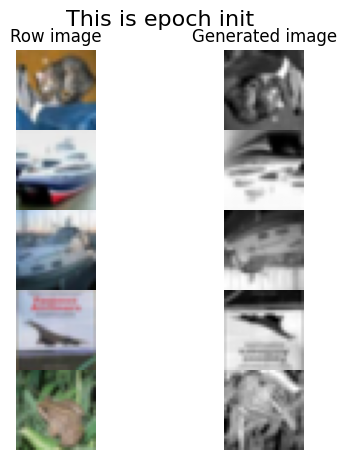

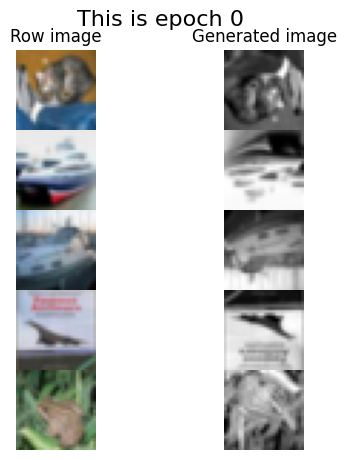

In [36]:

save_image_clbk_path = "{}/out/real_image".format(LCL_PATH)
tmp = SaveFakeImage(get_target_transform(), test_ds, out_transform, device, size=5, path=save_image_clbk_path)
tmp.on_epoch_end(0, None)

## Autoencode

This is the classification model, which leverages PyTorch Image Models to create backbones.

Beware that not all backbones have a fully connected (fc) layer at the end. Some of them do, especially the resnet variants.

In [22]:

unet_conf = dict(
    input=dict(
        img_shape=(3, 32, 32), 
        out_channels=64, 
        frame_dim=(4, 4), 
        num_heads=4),
    encode=dict(
        enc_conv_1x=dict(in_channels=64, 
                     expansion=4, 
                     stride=2, 
                     intermediate_channels=32, 
                     num_residual_blocks=1),
        enc_conv_2x=dict(in_channels=128, 
                     expansion=4, 
                     stride=2, 
                     intermediate_channels=64, 
                     num_residual_blocks=1),
    ),
    decode=dict(
        dec_bottleneck=dict(in_channels=256, 
                     expansion=4, 
                     stride=1, 
                     intermediate_channels=64, 
                     num_residual_blocks=1),
        dec_conv_2x=dict(in_channels=256, 
                     expansion=4, 
                     stride=2, 
                     intermediate_channels=32, 
                     num_residual_blocks=1),
        dec_conv_1x=dict(in_channels=128, 
                     expansion=4, 
                     stride=2, 
                     intermediate_channels=16, 
                     num_residual_blocks=1),
    ),
    output=dict(in_channels=64, out_channels=1)
)

In [23]:

model = UNetResNet("unet_resnet_numresnet_blocks", **unet_conf)

#criterion = nn.MSELoss()
device = torch.device("cuda")

### Adam + CosineAnnealingLR + MAEMSELoss

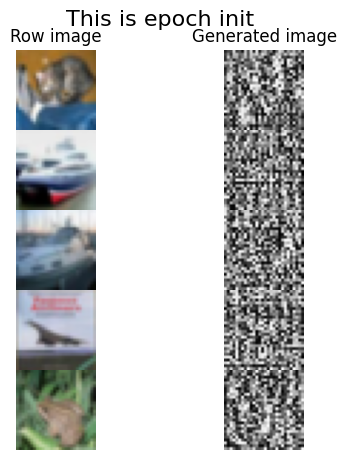

Using device: cuda


In [33]:

criterion = MAEMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizers = [optimizer]

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10000, eta_min=1e-9)
lr_schedulers = [lr_scheduler]

save_image_clbk_path = "{}/logs/adam_ca_maemse_v1".format(LCL_PATH)
save_model_clbk_path = "{}/logs/adam_ca_maemse_v1.pth".format(LCL_PATH)

callbacks = [ShowLogs("Adam"), 
             SaveFakeImage(model, test_ds, out_transform, device, size=5, path=save_image_clbk_path),
             SaveModelByBestKey(model, save_model_clbk_path, key="val_mae"),
             EarlyStoping(
                      monitor="val_mae",
                      mode="min",
                      patience=30,
                      min_delta=0.005,
                      verbose=True,)
            ]
metrics   = {"mse": MSEMetrics(name="mean_squared_error"), "mae": MAEMetrics(name="mean_absolute_error")}

trainer_obj = UnsupervisedClbkMTrainer(
         model,
         optimizers,
         criterion,
         device,
         callbacks=callbacks,
         metrics=metrics,
         model_type="raw",
         inputs_transforms=v2.CutMix(num_classes=10), 
         target_transforms=get_target_transform(), 
         lr_schedulers=lr_schedulers,
   )

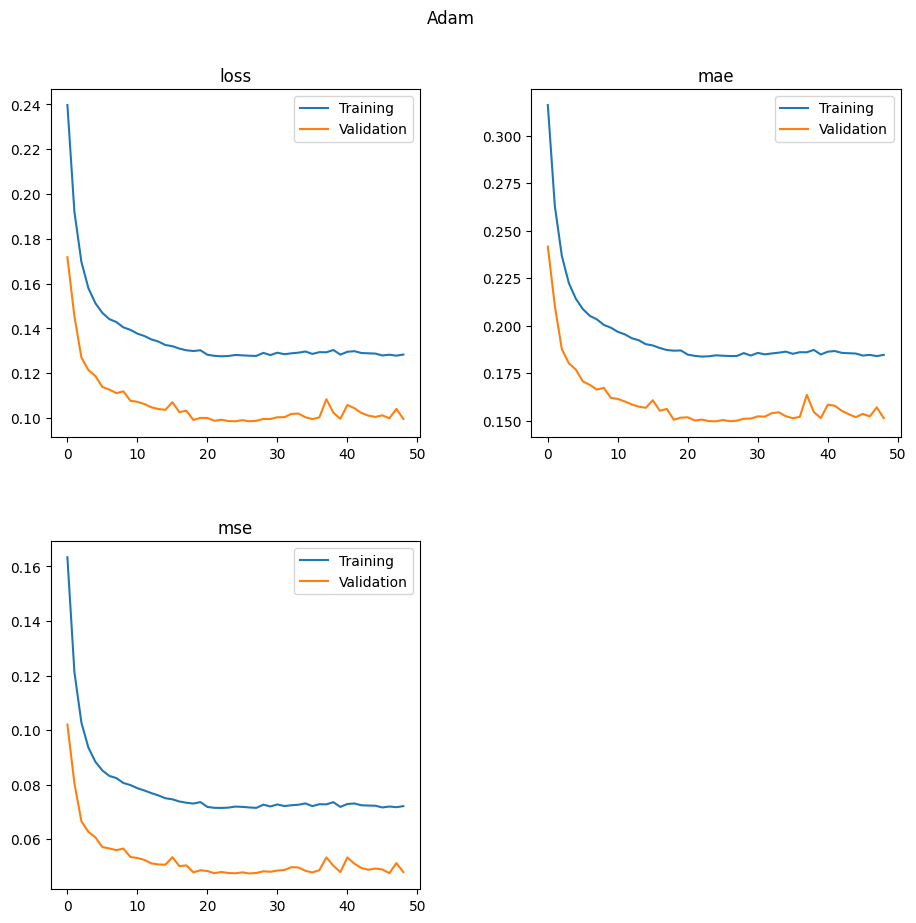

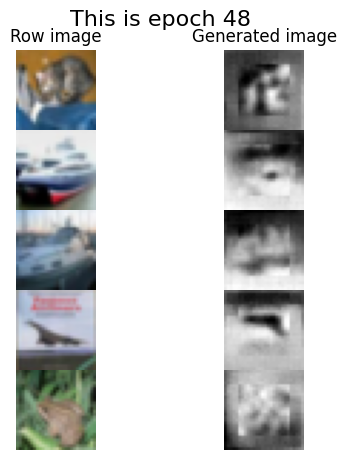

[EarlyStopping] Epoch 48: no improvement (30/30)
EarlyStoping


In [34]:

EPOCH = 200
trainer_obj.run(train_dl, test_dl, EPOCH)

In [57]:

# get some random training images
dataiter = iter(test_dl)
images, labels = next(dataiter)

writer = SummaryWriter("test/test")
model = model.to("cpu")
writer.add_graph(model, images)
writer.close()

In [23]:
summary(
    model,
    input_size=(1, 3, 32, 32),  # adjust to your input
    device="cuda"                # or "cpu"
)

Layer (type:depth-idx)                                       Output Shape              Param #
UNetResNet                                                   [1, 1, 28, 28]            --
├─AttUnetInput: 1-1                                          [1, 64, 32, 32]           --
│    └─TransformerEncoderLayer: 2-1                          [1, 64, 48]               --
│    │    └─MultiheadAttention: 3-1                          [1, 64, 48]               9,216
│    │    └─Dropout: 3-2                                     [1, 64, 48]               --
│    │    └─LayerNorm: 3-3                                   [1, 64, 48]               48
│    │    └─Linear: 3-4                                      [1, 64, 96]               4,608
│    │    └─LeakyReLU: 3-5                                   [1, 64, 96]               --
│    │    └─Dropout: 3-6                                     [1, 64, 96]               --
│    │    └─Linear: 3-7                                      [1, 64, 48]               4,

In [29]:

x = torch.randn(1, 3, 32, 32).to(device)
y = model(x)

dot = make_dot(y, params=dict(model.named_parameters()))
dot.format = "png"
dot.render("model_graph")

'model_graph.png'

#### Post procesing

In [41]:


tta_obj = TTA(model, [])

in_shape = (1, 3, 32, 32)
def build_model():
    return UNetResNet("unet_resnet_numresnet_blocks", **unet_conf)
save_model_clbk_path = "{}/logs/adam_ca_maemse_v1.pth".format(LCL_PATH)
select_model_obj = SelectModelType(save_model_clbk_path, build_model, in_shape=in_shape)

metrics = {"mae": MAEMetrics(name="mean_absolute_error")}
finetune_tta_obj = FinetuneTTA(test_dl, tta_obj, select_model_obj, 
                               metrics=metrics, 
                               target_transforms=get_target_transform(),
                               type_tti="generator")

##### Speed test

In [ ]:

model_types = (
    "raw",
    #"scripted",
    #"scripted",
    "traced",
    "traced",
    #"frozen",
    #"frozen",
    #"optimized_for_inference",
    #"optimized_for_inference",
    "compiled",
    "compiled",
)
dtypes = (
    torch.bfloat16,
    torch.half,
    torch.float32
)
tta_types = (
    "basic",
)
devices = (
    torch.device("cuda"),
    torch.device("cpu"),
)
# do speed test
#finetune_tta_obj(model_types, dtypes, tta_types, devices)
speed_prety_table_obj = finetune_tta_obj.by(model_types, dtypes, tta_types, devices, 
                    ord_prod=dict(model_type=3, dtype=1, tta_type=2, device=0),)

Speed experiments:   0%|          | 0/30 [00:00<?, ?it/s]

Error: 'Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!', model type 'raw' failed on 'torch.bfloat16' on 'cuda'
Error: 'Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!', model type 'traced' failed on 'torch.bfloat16' on 'cuda'
Error: 'Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!', model type 'traced' failed on 'torch.bfloat16' on 'cuda'
Error: 'Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!', model type 'compiled' failed on 'torch.bfloat16' on 'cuda'
Error: 'Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!', model type 'compiled' failed on 'torch.bfloat16' on 'cuda'
Error: 'Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!', model type 'raw' failed on 'torch.float16' on 'cuda'
Error: 'Expected all tensors to

### Adam + CosineAnnealingLR + KLDivLoss

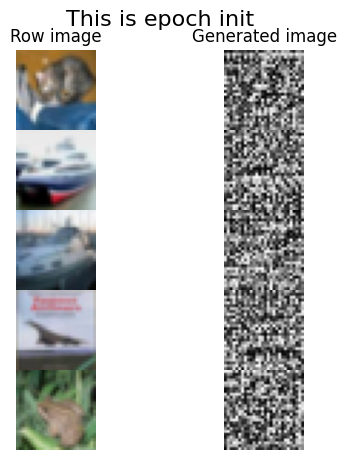

Using device: cuda


In [26]:

criterion = KLDivLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizers = [optimizer]

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10000, eta_min=1e-9)
lr_schedulers = [lr_scheduler]

path = "{}/logs/adam_CosineAnnealingLR_KLDivLoss_28x28".format(LCL_PATH)

callbacks = [ShowLogs("Adam"), SaveFakeImage(model, test_ds, out_transform, device, size=5, path=path)]
metrics   = {"mse": MSEMetrics(name="mean_squared_error"), "mae": MAEMetrics(name="mean_absolute_error")}

trainer_obj = UnsupervisedClbkMTrainer(
         model,
         optimizers,
         criterion,
         device,
         callbacks=callbacks,
         metrics=metrics,
         model_type="raw",
         inputs_transforms=v2.CutMix(num_classes=10), 
         target_transforms=get_target_transform(), 
         lr_schedulers=lr_schedulers,
   )

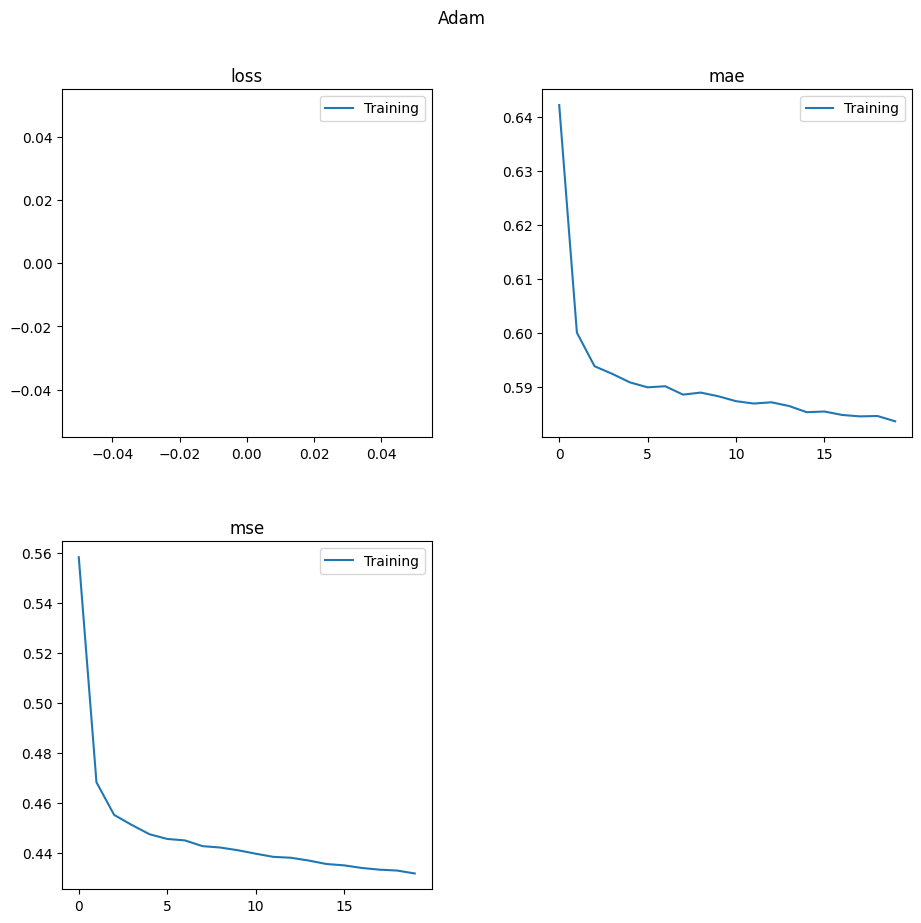

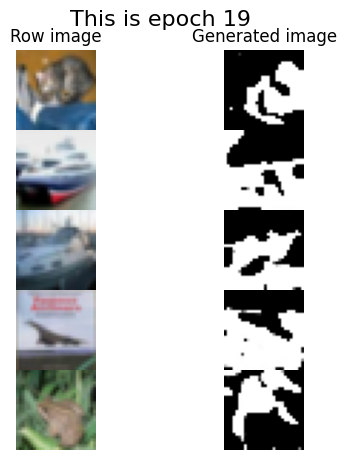

In [27]:

EPOCH = 20
trainer_obj.run(train_dl, EPOCH)

### Adam + CosineAnnealingLR + SSIMLoss

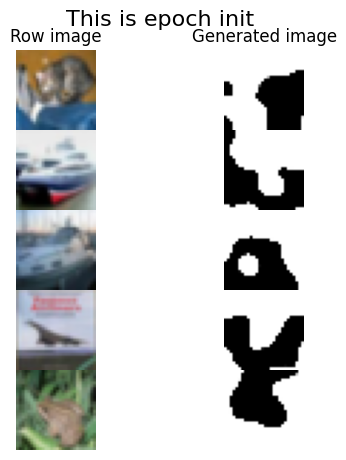

Using device: cuda


In [83]:

criterion = SSIMLoss(1, reduction="mean", max_val=2.34)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizers = [optimizer]

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10000, eta_min=1e-9)
lr_schedulers = [lr_scheduler]

path = "{}/logs/adam_CosineAnnealingLR_SSIMLoss_28x28".format(LCL_PATH)

callbacks = [ShowLogs("Adam"), 
             SaveFakeImage(model, test_ds, out_transform, device, size=5, path=path),
             EarlyStoping(
                      monitor="val_mae",
                      mode="min",
                      patience=5,
                      percent_delta=0.05,
                      verbose=True,
                   )]
metrics   = {"mse": MSEMetrics(name="mean_squared_error"), 
             "mae": MAEMetrics(name="mean_absolute_error"),}

trainer_obj = UnsupervisedClbkMTrainer(
         model,
         optimizers,
         criterion,
         device,
         callbacks=callbacks,
         metrics=metrics,
         model_type="raw",
         inputs_transforms=v2.CutMix(num_classes=10), 
         target_transforms=get_target_transform(), 
         lr_schedulers=lr_schedulers,
   )

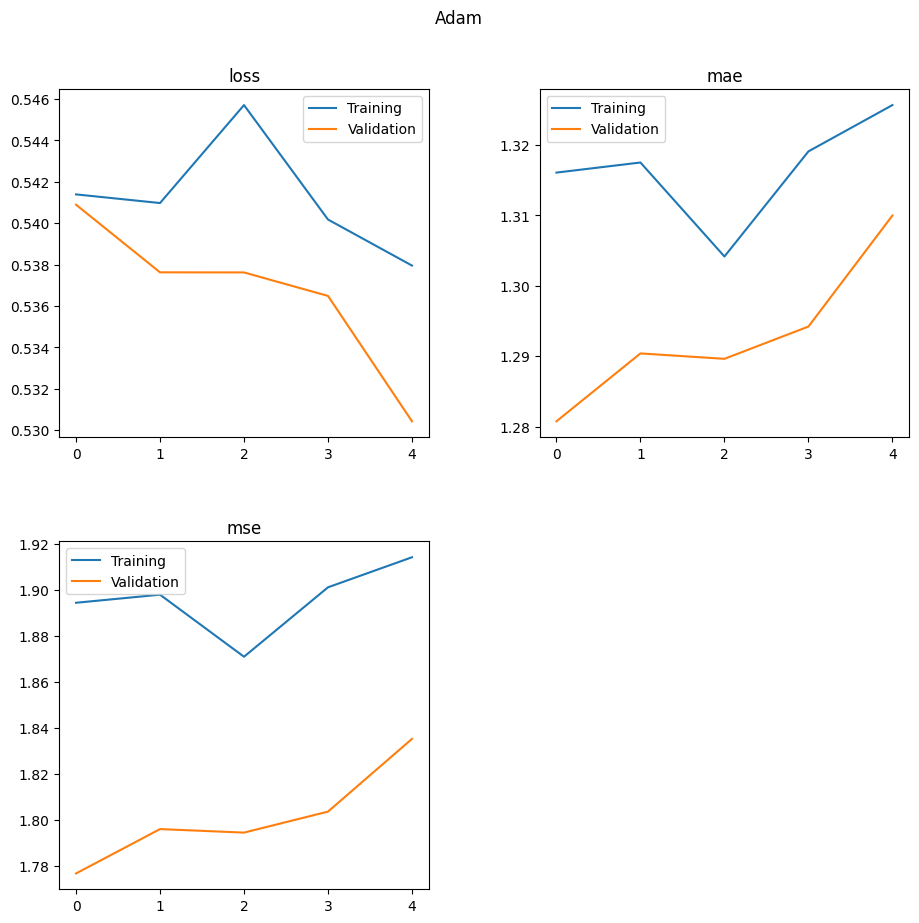

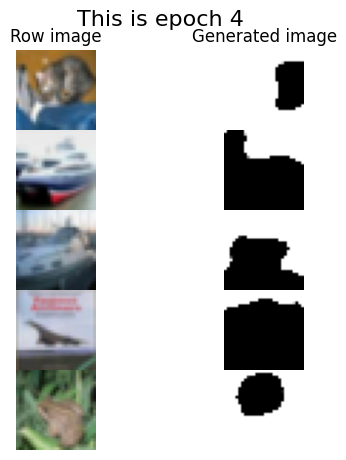

[EarlyStopping] Epoch 4: no improvement (5/5)
EarlyStoping


In [84]:

EPOCH = 200
trainer_obj.run(train_dl, test_dl, EPOCH)

In [ ]:
1.295532 < 1.295350

### Adam + MultiStepLR

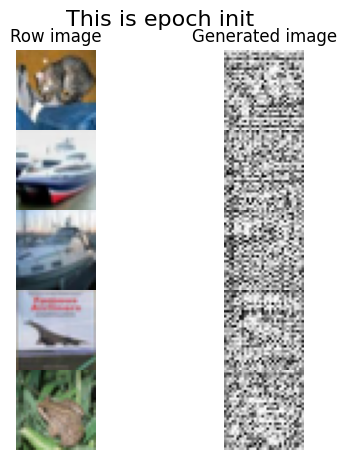

Using device: cuda


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [25]:

EPOCH = 300

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
optimizers = [optimizer]

lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 25, 50, 75, 100, 200], gamma=0.1)
lr_schedulers = [lr_scheduler]

path = "{}/logs/adam_MultiStepLR".format(LCL_PATH)

callbacks = [ShowLogs("Adam"), SaveFakeImage(model, test_ds, out_transform, device, size=5, path=path)]
metrics   = {"mse": MSEMetrics(name="mean_squared_error"), "mae": MAEMetrics(name="mean_absolute_error")}

trainer_obj = UnsupervisedClbkMTrainer(
         model,
         optimizers,
         criterion,
         device,
         callbacks=callbacks,
         metrics=metrics,
         model_type="raw",
         inputs_transforms=v2.CutMix(num_classes=10), 
         target_transforms=get_target_transform(), 
         lr_schedulers=lr_schedulers,
   )

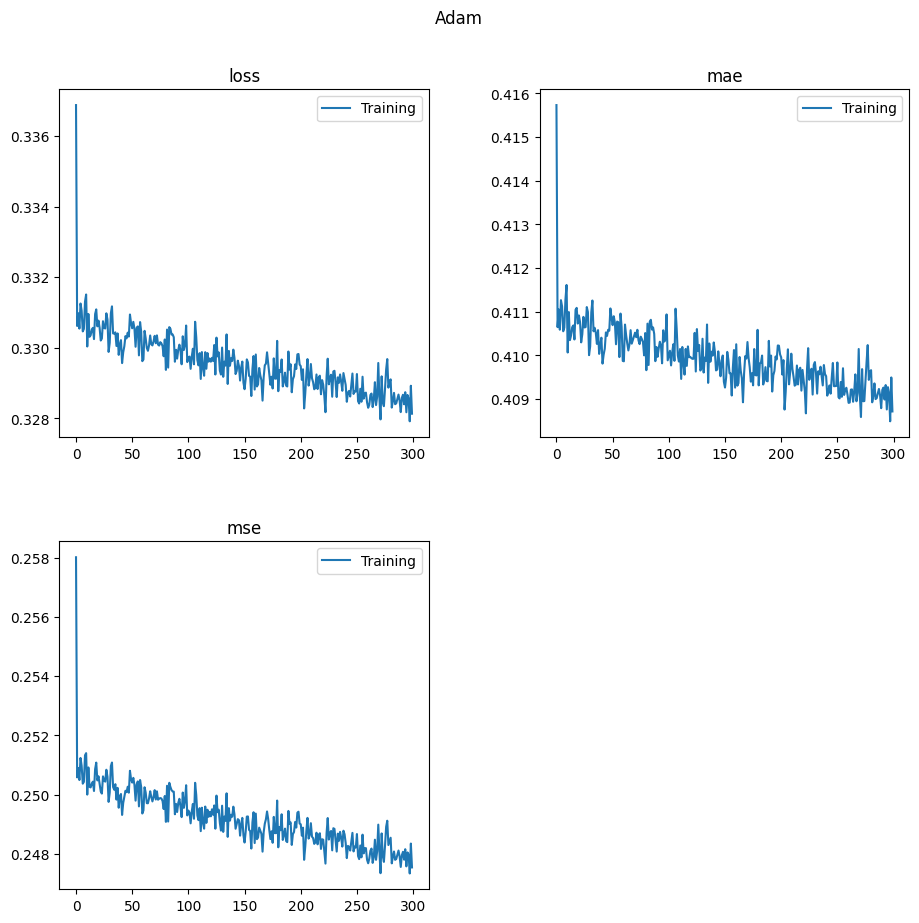

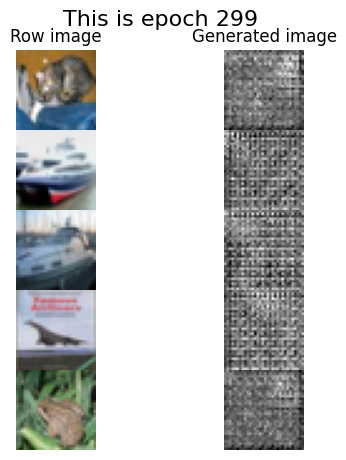

In [26]:

trainer_obj.run(train_dl, EPOCH)

In [ ]:
tmp = 

### Advanced

In [39]:

d_size = {}
for p in list(model.parameters()):
    d_size[len(p.shape)] = 1
    print("shape {}, size {}".format(p.shape, len(p.shape)))
d_size.keys()

shape torch.Size([64, 3, 3, 3]), size 4
shape torch.Size([64]), size 1
shape torch.Size([64]), size 1
shape torch.Size([144, 48]), size 2
shape torch.Size([48, 48]), size 2
shape torch.Size([96, 48]), size 2
shape torch.Size([48, 96]), size 2
shape torch.Size([48]), size 1
shape torch.Size([48]), size 1
shape torch.Size([144, 48]), size 2
shape torch.Size([48, 48]), size 2
shape torch.Size([96, 48]), size 2
shape torch.Size([48, 96]), size 2
shape torch.Size([48]), size 1
shape torch.Size([48]), size 1
shape torch.Size([144, 48]), size 2
shape torch.Size([48, 48]), size 2
shape torch.Size([96, 48]), size 2
shape torch.Size([48, 96]), size 2
shape torch.Size([48]), size 1
shape torch.Size([48]), size 1
shape torch.Size([144, 48]), size 2
shape torch.Size([48, 48]), size 2
shape torch.Size([96, 48]), size 2
shape torch.Size([48, 96]), size 2
shape torch.Size([48]), size 1
shape torch.Size([48]), size 1
shape torch.Size([144, 48]), size 2
shape torch.Size([48, 48]), size 2
shape torch.Siz

dict_keys([4, 1, 2])

In [38]:

EPOCH = 200
whiten_bias_train_epochs = 50
total_train_steps = np.ceil(EPOCH * len(train_dl)).astype(int)
whiten_bias_train_steps = np.ceil(whiten_bias_train_epochs * len(train_dl)).astype(int)

bias_lr = 0.00053
att_lr  = 0.00067
wd = 2e-9 * BATCH_SIZE
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
att_params    = [p for p in model.parameters() if len(p.shape) == 2 and p.requires_grad]
norm_biases   = [p for p in model.parameters() if len(p.shape) == 1 and p.requires_grad]
param_configs = [dict(params=att_params,  lr=att_lr , weight_decay=wd/att_lr),
                 dict(params=norm_biases, lr=bias_lr, weight_decay=wd/bias_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.00024, momentum=0.6, nesterov=True, ns_steps=3)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]
        
lr_scheduler1 = WhitenLrScheduler(optimizers, total_train_steps, whiten_bias_train_steps)
lr_schedulers = [lr_scheduler1]

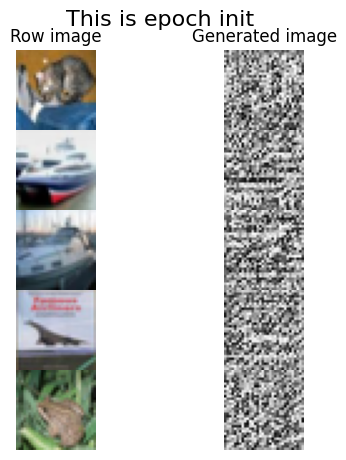

Using device: cuda


In [39]:

path = "{}/logs/advanced_muon_1".format(LCL_PATH)

callbacks = [ShowLogs("Advance separate optimizer"), SaveGrayImg(model, test_ds, out_transform, device, size=5, path=path)]
metrics   = {"mse": MSEMetrics(name="mean_squared_error"), "mae": MAEMetrics(name="mean_absolute_error")}

trainer_obj = UnupervisedClbkMTrainer(
         model,
         optimizers,
         criterion,
         device,
         callbacks=callbacks,
         metrics=metrics,
         model_type="raw",
         inputs_transforms=v2.CutMix(num_classes=10), 
         target_transforms=get_target_transform(), 
         lr_schedulers=lr_schedulers,
   )

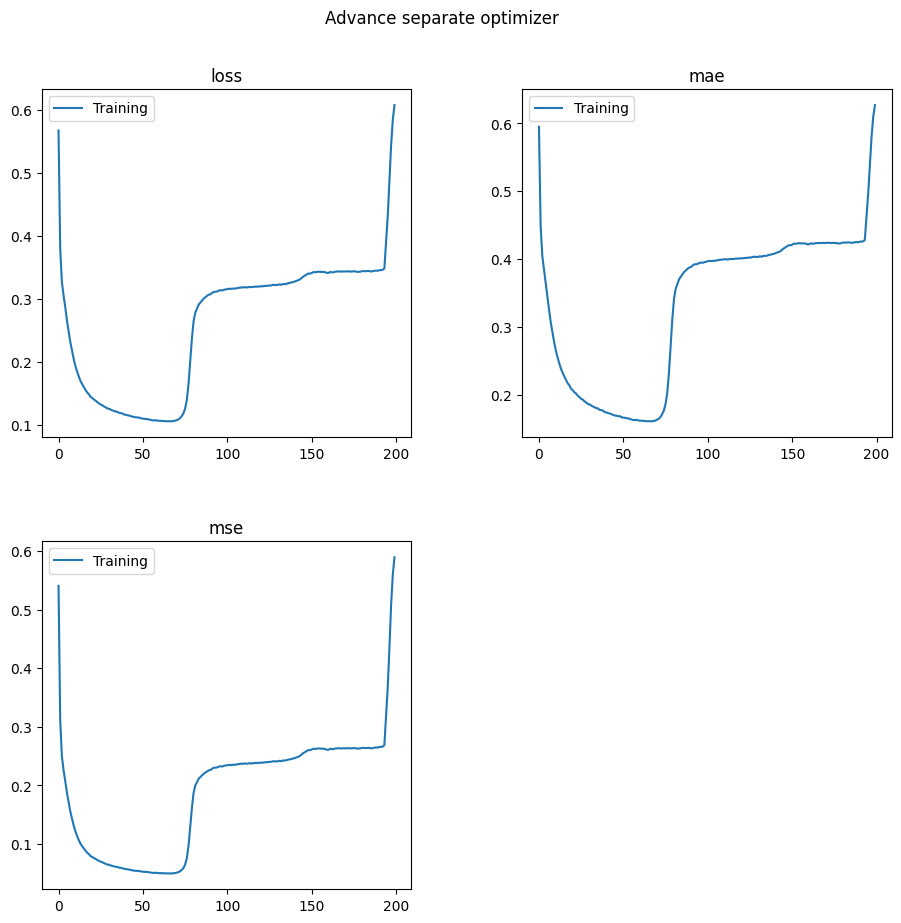

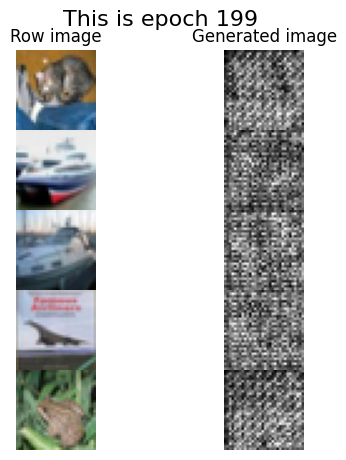

In [40]:

trainer_obj.run(train_dl, EPOCH)

### Advanced

In [34]:

EPOCH = 300

bias_lr = 0.0053
att_lr  = 0.0067
wd = 2e-9 * BATCH_SIZE
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
att_params    = [p for p in model.parameters() if len(p.shape) == 2 and p.requires_grad]
norm_biases   = [p for p in model.parameters() if len(p.shape) == 1 and p.requires_grad]
param_configs = [dict(params=att_params,  lr=att_lr , weight_decay=wd/att_lr),
                 dict(params=norm_biases, lr=bias_lr, weight_decay=wd/bias_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.0024, momentum=0.6, nesterov=True, ns_steps=3)
optimizers = [optimizer1, optimizer2]

lr_scheduler1 = torch.optim.lr_scheduler.MultiStepLR(optimizer1, milestones=[3, 10, 50, 100], gamma=0.1)
lr_scheduler2 = torch.optim.lr_scheduler.MultiStepLR(optimizer2, milestones=[5, 15, 50, 75, 100, 150], gamma=0.1)
lr_schedulers = [lr_scheduler1, lr_scheduler2]

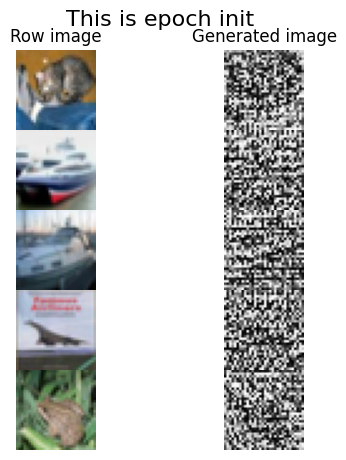

Using device: cuda


In [35]:

path = "{}/logs/test_advanced_muon_MultiStepLR".format(LCL_PATH)

callbacks = [ShowLogs("Advance separate optimizer"), SaveGrayImg(model, test_ds, out_transform, device, size=5, path=path)]
metrics   = {"mse": MSEMetrics(name="mean_squared_error"), "mae": MAEMetrics(name="mean_absolute_error")}

trainer_obj = UnupervisedClbkMTrainer(
         model,
         optimizers,
         criterion,
         device,
         callbacks=callbacks,
         metrics=metrics,
         model_type="raw",
         inputs_transforms=v2.CutMix(num_classes=10), 
         target_transforms=get_target_transform(), 
         lr_schedulers=lr_schedulers,
   )

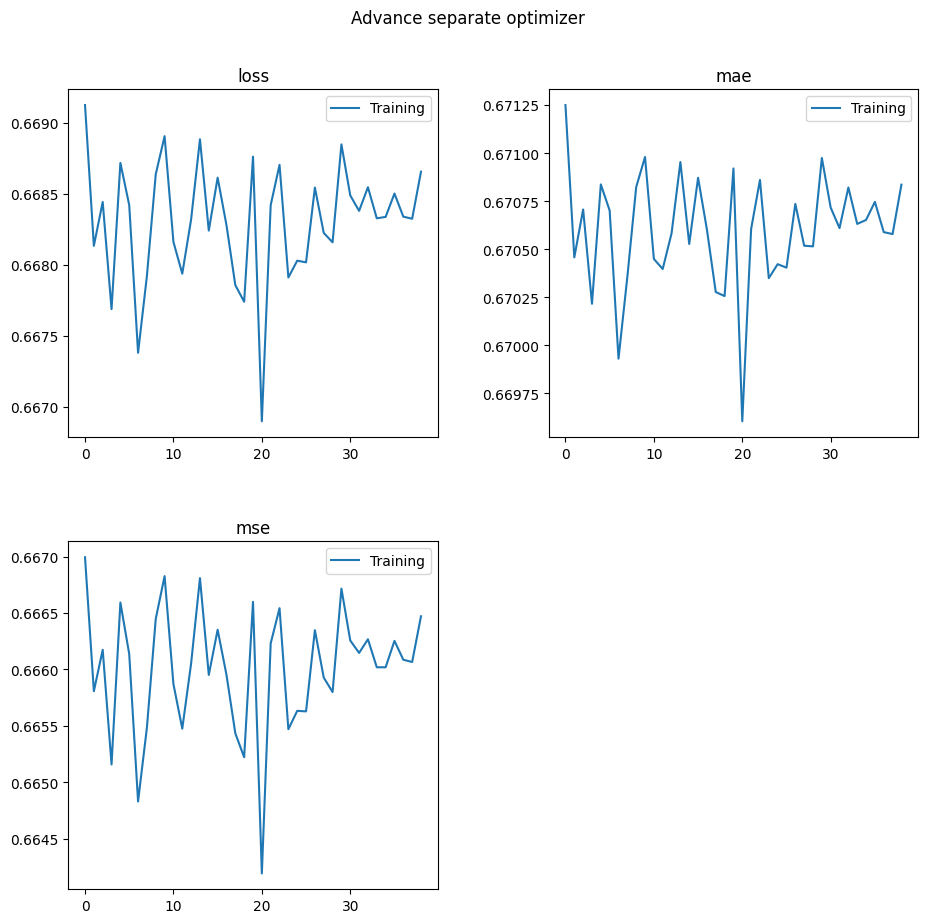

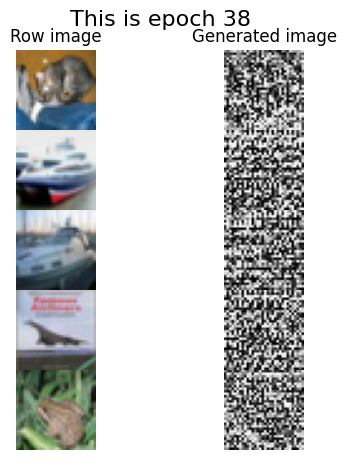

KeyboardInterrupt: 

In [36]:

trainer_obj.run(train_dl, EPOCH)

### Advanced

In [21]:

EPOCH = 300

bias_lr = 0.001
att_lr  = 0.001
wd = 2e-9 * BATCH_SIZE
# Create optimizers and learning rate schedulers
filter_params = [p for p in model.parameters() if len(p.shape) == 4 and p.requires_grad]
att_params    = [p for p in model.parameters() if len(p.shape) == 2 and p.requires_grad]
norm_biases   = [p for p in model.parameters() if len(p.shape) == 1 and p.requires_grad]
param_configs = [dict(params=att_params,  lr=att_lr , weight_decay=wd/att_lr),
                 dict(params=norm_biases, lr=bias_lr, weight_decay=wd/bias_lr)]
optimizer1 = torch.optim.SGD(param_configs, momentum=0.85, nesterov=True)
optimizer2 = Muon(filter_params, lr=0.001, momentum=0.6, nesterov=True, ns_steps=3)
optimizers = [optimizer1, optimizer2]
for opt in optimizers:
    for group in opt.param_groups:
        group["initial_lr"] = group["lr"]

lr_scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=10000, eta_min=1e-9)
lr_scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=10000, eta_min=1e-9)
lr_schedulers = [lr_scheduler1, lr_scheduler2]

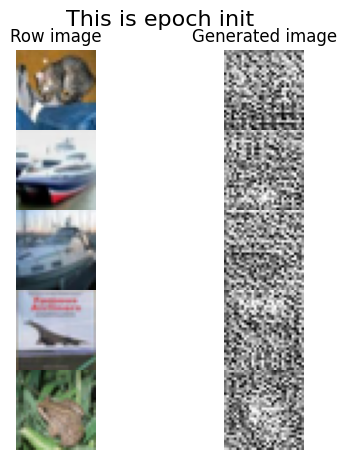

Using device: cuda


/home/gheorghe/venvs/torch_env/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [24]:

path = "{}/logs/advanced_muon_CosineAnnealingLR_1e-3".format(LCL_PATH)

callbacks = [ShowLogs("Advance separate optimizer"), SaveFakeImage(model, test_ds, out_transform, device, size=5, path=path)]
metrics   = {"mse": MSEMetrics(name="mean_squared_error"), "mae": MAEMetrics(name="mean_absolute_error")}

trainer_obj = UnsupervisedClbkMTrainer(
         model,
         optimizers,
         criterion,
         device,
         callbacks=callbacks,
         metrics=metrics,
         model_type="raw",
         inputs_transforms=v2.CutMix(num_classes=10), 
         target_transforms=get_target_transform(), 
         lr_schedulers=lr_schedulers,
   )

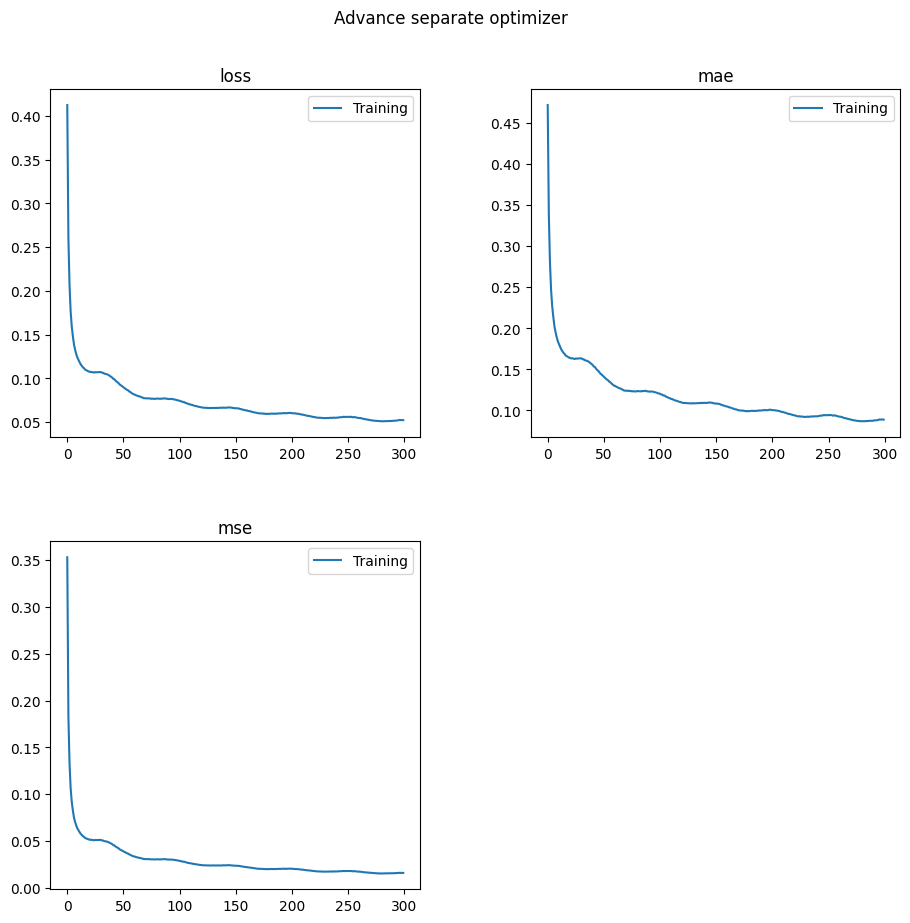

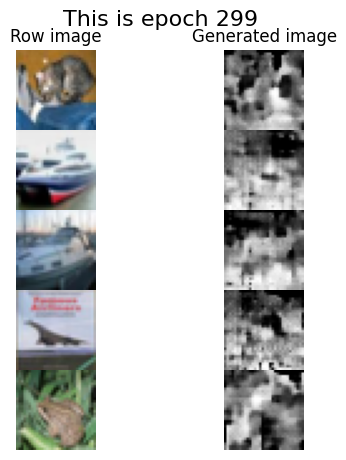

In [25]:

trainer_obj.run(train_dl, EPOCH)